# 2D Guided-Drift Mechanistic Sandbox

Replace the learned high-dimensional prior with a fully analytic 2D GMM so every quantity
(density, score, geometry) is interpretable and controllable.

Uses properly interleaved experiment sequences (`make_high_diversity_sequences`)
with ~50% repetition rate, matching the real experimental design.

**Experiment blocks:**
1. Baseline ISI sweep (cosine metric)
2. Metric ablation: cosine vs Euclidean
3. Raw vs unit-normalised score ablation
4. Matched vs mismatched prior
5. Item susceptibility analysis
6. Trajectory diagnostics

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from src.model.analytic_gmm_2d import AnalyticGMM2D, make_default_gmm, make_mismatched_gmm
from src.model.score_adapter_2d import ScoreAdapter2D
from utls.sandbox_2d_data import make_2d_grid_stimuli, compute_geometry_descriptors
from utls.runners_2d import run_model_core_2d, run_2d_isi_sweep
from utls.analysis_2d import (
    dprime_by_isi_curve,
    plot_prior_with_score_field,
    plot_dprime_curves,
    prior_mismatch_benchmark,
    item_susceptibility_analysis,
    plot_item_susceptibility,
)

SAVE_DIR = '../reports/figures/2d_sandbox'
os.makedirs(SAVE_DIR, exist_ok=True)
print('Ready.')



Ready.


## 1. Define the GMM prior and visualise

In [3]:
#defaul parameters
DEFAULT_MEANS = [
    [-2.5, 0.0],   # broad component (centre-left)
    [2.0,  2.0],   # tight component (upper-right)
    [2.0, -2.0],   # tight component (lower-right)
]

DEFAULT_COVARIANCES = [
    [[1.5, 0.0], # broad
     [0.0, 1.5]],   
    
    [[0.4, 0.0], # tight
     [0.0, 0.4]],   
    
    [[0.4, 0.0],  # tight
     [0.0, 0.4]],  
]

DEFAULT_WEIGHTS = [0.4, 0.3, 0.3]


gmm = make_default_gmm()

####
### OR IF YOU WANT SPECIFY SOMETHING MORE EXACT
## gmm = AnalyticGMM2D(means = DEFAULT_MEANS,
##  covariances = DEFAULT_COVARIANCES,
##  weights = DEFAULT_WEIGHTS)
## 

print(f'Components: {gmm.K}')
print(f'Means:\n{gmm.means.numpy()}')
print(f'Weights: {gmm.weights.numpy()}')

# Generate stimuli
X0, name_to_idx, stimulus_pool = make_2d_grid_stimuli()
descriptors = compute_geometry_descriptors(X0, gmm)
print(f'\nStimuli: {len(X0)} points')
descriptors.head(10)

Components: 3
Means:
[[-2.5  0. ]
 [ 2.   2. ]
 [ 2.  -2. ]]
Weights: [0.4 0.3 0.3]

Stimuli: 80 points


,point_id,x,y,log_density,score_norm,dist_to_nearest_mean,posterior_entropy
0,pt_00,-4.0,-4.0,-9.242966,2.848001,4.272002,1.020017e-17
1,pt_01,-4.0,-3.0,-6.909633,2.236068,3.354102,4.066946e-17
2,pt_02,-4.0,-2.0,-5.242966,1.666667,2.500000,2.708037e-17
3,pt_03,-4.0,-1.0,-4.242966,1.201850,1.802776,3.007752e-18
4,pt_04,-4.0,0.0,-3.909633,1.000000,1.500000,1.107413e-19
5,pt_05,-4.0,1.0,-4.242966,1.201850,1.802776,3.007752e-18
6,pt_06,-4.0,2.0,-5.242966,1.666667,2.500000,2.708037e-17
7,pt_07,-4.0,3.0,-6.909633,2.236068,3.354102,4.066946e-17
8,pt_08,-4.0,4.0,-9.242966,2.848001,4.272002,1.020017e-17
9,pt_09,-3.0,-4.0,-8.576300,2.687419,4.031129,3.522760e-12


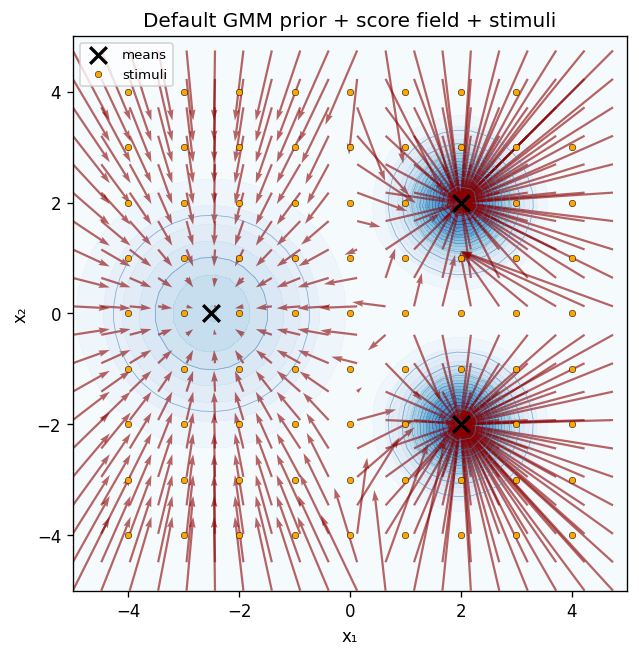

In [4]:
fig, ax = plt.subplots(figsize=(7, 6))
plot_prior_with_score_field(gmm, X0=X0, grid_n=40, ax=ax,
                            title='Default GMM prior + score field + stimuli')
fig.savefig(f'{SAVE_DIR}/prior_score_field.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Validation checks

In [4]:
# Finite-difference score verification
eps = 1e-5
rng = np.random.default_rng(42)
max_err = 0.0
for _ in range(20):
    x = torch.tensor(rng.uniform(-4, 4, size=2), dtype=torch.float64)
    analytic = gmm.score(x).numpy()
    numerical = np.zeros(2)
    for d in range(2):
        xp, xm = x.clone(), x.clone()
        xp[d] += eps; xm[d] -= eps
        numerical[d] = (gmm.log_prob(xp).item() - gmm.log_prob(xm).item()) / (2*eps)
    err = np.max(np.abs(analytic - numerical))
    max_err = max(max_err, err)
print(f'Max finite-diff error across 20 points: {max_err:.2e}')
assert max_err < 1e-4, 'Score verification FAILED'

Max finite-diff error across 20 points: 4.30e-10


In [5]:
# Score adapter shape checks
adapter = ScoreAdapter2D(gmm, normalize=True)
s1 = adapter.forward(torch.tensor([1.0, -1.0]))
s2 = adapter.forward(torch.randn(5, 2))
s4 = adapter.forward(torch.randn(3, 1, 1, 2))
print(f'[D] → {s1.shape}, [B,D] → {s2.shape}, [B,1,1,D] → {s4.shape}')
print(f'Unit-norm check: {s2.norm(dim=1).numpy()}')
print('All shape checks passed.')

[D] → torch.Size([2]), [B,D] → torch.Size([5, 2]), [B,1,1,D] → torch.Size([3, 1, 1, 2])
Unit-norm check: [1. 1. 1. 1. 1.]
All shape checks passed.


## 3. Baseline ISI sweep

In [17]:
# Two-parameter noise model (matching the paper):
#   σ₀ = encoding noise (applied once at memory insertion)
#   σ  = diffusive noise (constant per-step noise during Langevin dynamics)
#   η  = drift step size (prior-driven drift magnitude)
SIGMA0 = 0.5       # encoding noise
SIGMA = 0.1        # diffusive noise per step
DRIFT_STEP = 0.02  # η in the paper
METRIC = 'cosine'  # matching the main model
ISI_VALUES = (0, 16)

adapter_norm = ScoreAdapter2D(gmm, normalize=False)

baseline = run_2d_isi_sweep(
    sigma0=SIGMA0, sigma=SIGMA,
    drift_step_size=DRIFT_STEP, score_model=adapter_norm,
    X0=X0, name_to_idx=name_to_idx, stimulus_pool=stimulus_pool,
    isi_values=ISI_VALUES, metric=METRIC,
    n_sequences=10, seq_length=81, min_pairs_per_isi=5,
    n_mc=2, seed=42,
)

isis, dps, sems = dprime_by_isi_curve(baseline)
print('ISI:', isis)
print('d\' :', np.round(dps, 3))
print('SEM:', np.round(sems, 3))

Aggregate ISI usage across all sequences:
  ISI -1: 270
  ISI 0: 422
  ISI 16: 118
ISI: [ 0 16]
d' : [0.26  0.396]
SEM: [0.053 0.093]


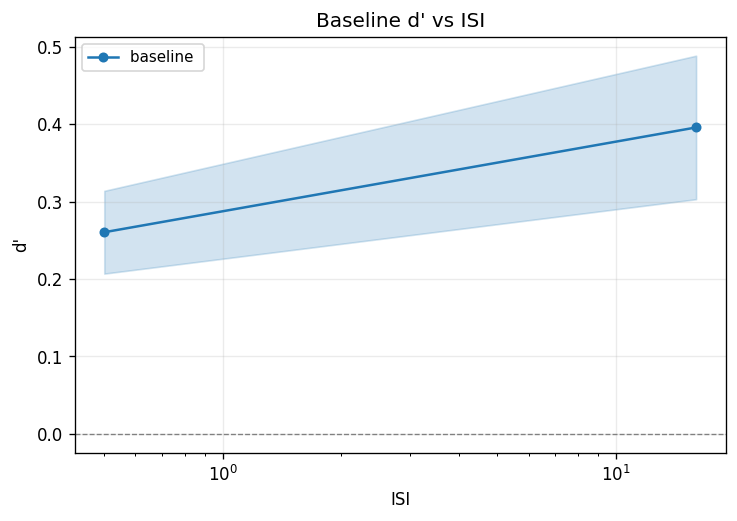

In [18]:
fig, ax = plt.subplots(figsize=(7, 4.5))
plot_dprime_curves({'baseline ': baseline}, title='Baseline d\' vs ISI', ax=ax)
fig.savefig(f'{SAVE_DIR}/baseline_dprime_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Ablation: Cosine vs Euclidean Metric

Aggregate ISI usage across all sequences:
  ISI -1: 270
  ISI 0: 422
  ISI 16: 118


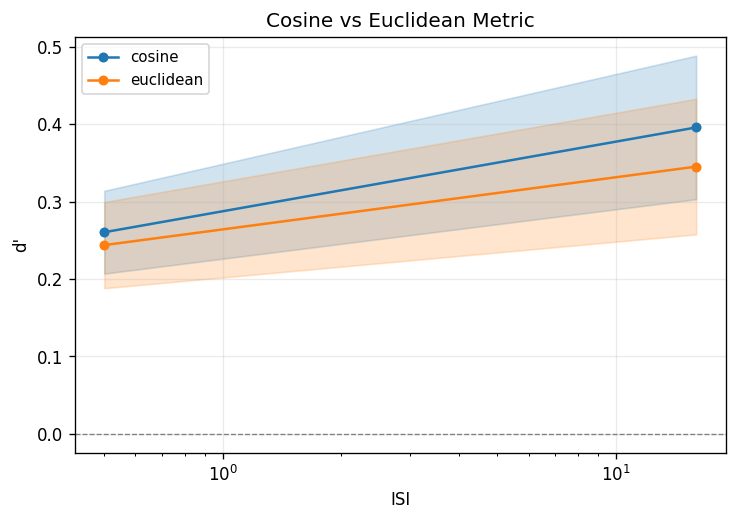

In [19]:
# Euclidean metric sweep
euclidean_sweep = run_2d_isi_sweep(
    sigma0=SIGMA0, sigma=SIGMA,
    drift_step_size=DRIFT_STEP, score_model=adapter_norm,
    X0=X0, name_to_idx=name_to_idx, stimulus_pool=stimulus_pool,
    isi_values=ISI_VALUES, metric='euclidean',
    n_sequences=10, seq_length=81, min_pairs_per_isi=5,
    n_mc=2, seed=42,
)

fig, ax = plt.subplots(figsize=(7, 4.5))
plot_dprime_curves({
    'cosine': baseline,
    'euclidean': euclidean_sweep,
}, title='Cosine vs Euclidean Metric', ax=ax)
fig.savefig(f'{SAVE_DIR}/metric_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Ablation: Raw vs Unit-Normalised Score

Aggregate ISI usage across all sequences:
  ISI -1: 270
  ISI 0: 422
  ISI 16: 118


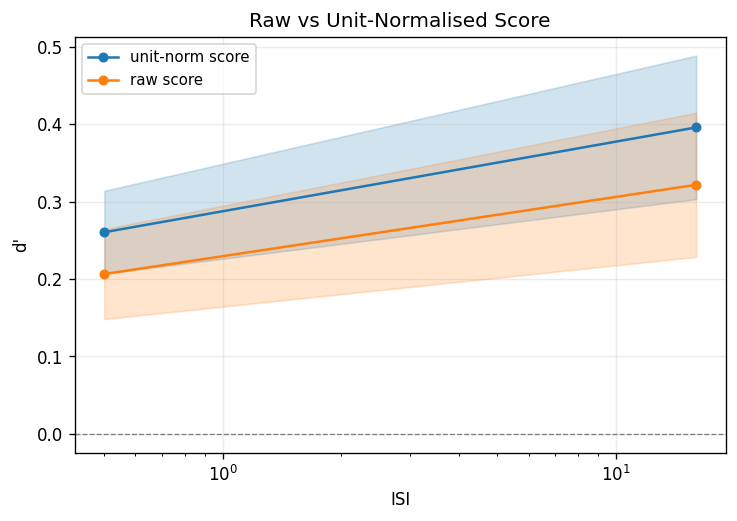

In [21]:
adapter_raw = ScoreAdapter2D(gmm, normalize=False)

raw_sweep = run_2d_isi_sweep(
    sigma0=SIGMA0, sigma=SIGMA,
    drift_step_size=DRIFT_STEP, score_model=adapter_raw,
    X0=X0, name_to_idx=name_to_idx, stimulus_pool=stimulus_pool,
    isi_values=ISI_VALUES, metric=METRIC,
    n_sequences=10, seq_length=81, min_pairs_per_isi=5,
    n_mc=2, seed=42,
)

fig, ax = plt.subplots(figsize=(7, 4.5))
plot_dprime_curves({
    'unit-norm score': baseline,
    'raw score': raw_sweep,
}, title='Raw vs Unit-Normalised Score', ax=ax)
fig.savefig(f'{SAVE_DIR}/raw_vs_unit_score.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Ablation: Matched vs Mismatched Prior

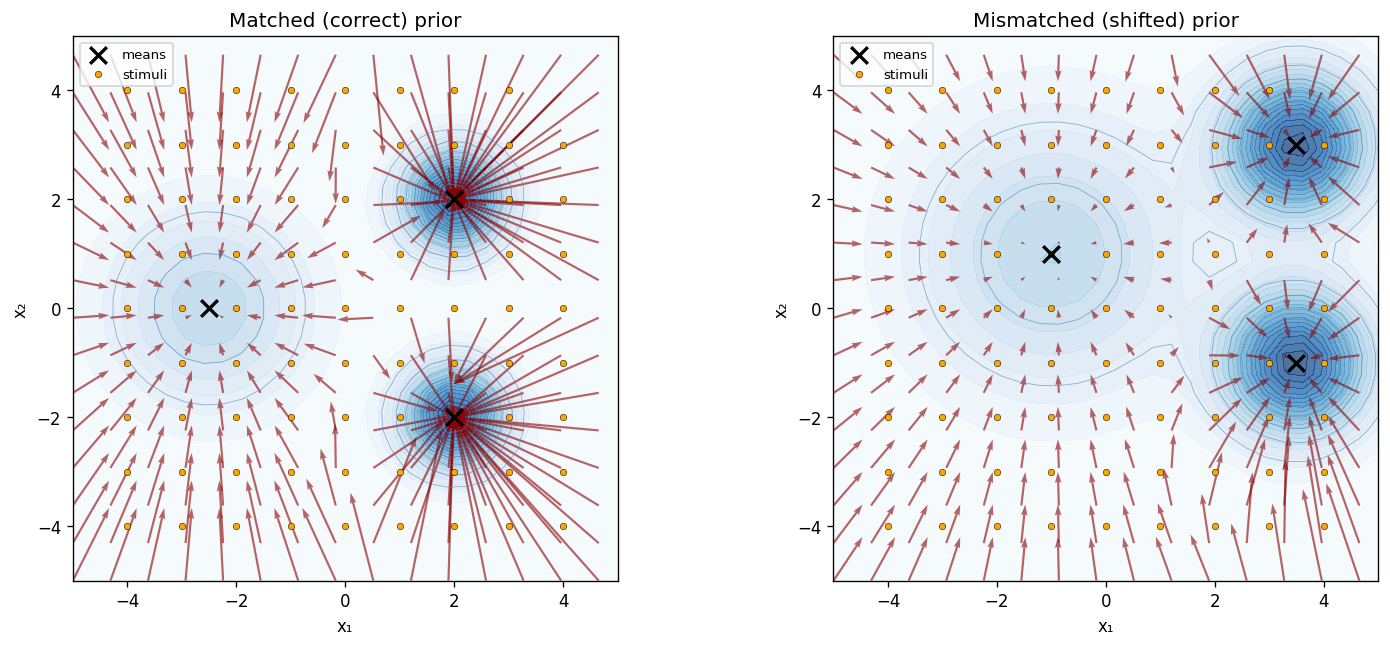

In [22]:
gmm_wrong = make_mismatched_gmm()

# Visualise both priors
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
plot_prior_with_score_field(gmm, X0=X0, ax=axes[0], title='Matched (correct) prior')
plot_prior_with_score_field(gmm_wrong, X0=X0, ax=axes[1], title='Mismatched (shifted) prior')
fig.tight_layout()
fig.savefig(f'{SAVE_DIR}/matched_vs_mismatched_priors.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
mismatch = prior_mismatch_benchmark(
    matched_gmm=gmm, mismatched_gmm=gmm_wrong,
    X0=X0, name_to_idx=name_to_idx, stimulus_pool=stimulus_pool,
    sigma0=SIGMA0, sigma=SIGMA,
    drift_step_size=DRIFT_STEP, metric=METRIC,
    isi_values=ISI_VALUES, n_mc=16, seed=42,
)

fig, ax = plt.subplots(figsize=(7, 4.5))
plot_dprime_curves(mismatch, title='Matched vs Mismatched Prior', ax=ax)
fig.savefig(f'{SAVE_DIR}/prior_mismatch_dprime.png', dpi=150, bbox_inches='tight')
plt.show()

Aggregate ISI usage across all sequences:
  ISI -1: 230
  ISI 0: 386
  ISI 16: 74


KeyboardInterrupt: 

## 7. Item Susceptibility Analysis

In [ ]:
suscept = item_susceptibility_analysis(
    score_model=adapter_norm, X0=X0, name_to_idx=name_to_idx,
    stimulus_pool=stimulus_pool, descriptors_df=descriptors,
    sigma0=SIGMA0, sigma=SIGMA,
    drift_step_size=DRIFT_STEP, metric=METRIC,
    isi_values=(1, 4, 16, 64), n_mc=16, seed=42,
)
print(f'Susceptibility rows: {len(suscept)}')
suscept.head(10)

In [ ]:
fig = plot_item_susceptibility(suscept)
if fig is not None:
    fig.savefig(f'{SAVE_DIR}/item_susceptibility.png', dpi=150, bbox_inches='tight')
    plt.show()

## 8. Trajectory Diagnostics (2D)

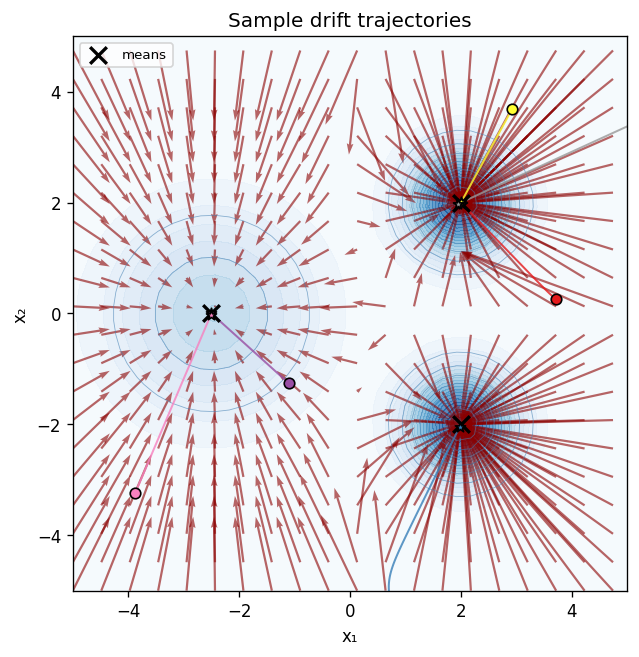

In [27]:
# Drift a few noisy points and visualise trajectories on the prior contour
n_traj = 6
rng_traj = np.random.default_rng(77)
indices = rng_traj.choice(len(X0), size=n_traj, replace=False)

fig, ax = plt.subplots(figsize=(7, 6))
plot_prior_with_score_field(gmm, grid_n=40, ax=ax, title='Sample drift trajectories')

n_drift_steps = 100
step_size = 0.05
noise_std = 5.0

colors = plt.cm.Set1(np.linspace(0, 1, n_traj))
for ci, idx in enumerate(indices):
    x_clean = X0[idx].to(torch.float64)
    x = x_clean + torch.randn_like(x_clean) * noise_std
    traj = [x.numpy().copy()]
    for _ in range(n_drift_steps):
        s = gmm.score(x)
        s_unit = s / (s.norm() + 1e-8)
        x = x + step_size * s_unit
        traj.append(x.numpy().copy())
    traj = np.array(traj)
    ax.plot(traj[:, 0], traj[:, 1], '-', color=colors[ci], lw=1.2, alpha=0.8)
    ax.scatter(traj[0, 0], traj[0, 1], s=40, color=colors[ci], edgecolors='k', zorder=10)
    ax.scatter(traj[-1, 0], traj[-1, 1], s=40, marker='*', color=colors[ci],
               edgecolors='k', zorder=10)

fig.savefig(f'{SAVE_DIR}/drift_trajectories_2d.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Summary

In [ ]:
print('='*60)
print('2D Guided-Drift Sandbox — Summary')
print('='*60)
print(f'\nGMM: {gmm.K} components, means={gmm.means.numpy().tolist()}')
print(f'Stimuli: {len(X0)} grid points in [-4,4]^2')
print(f'\nModel params (two-parameter noise model):')
print(f'  σ₀ = {SIGMA0} (encoding noise)')
print(f'  σ  = {SIGMA} (diffusive noise per step)')
print(f'  η  = {DRIFT_STEP} (drift step size)')
print(f'\nBaseline d\' by ISI:')
for isi, dp, sem in zip(baseline["isi_values"], baseline["dprime_mean"], baseline["dprime_sem"]):
    print(f'  ISI={isi:3d}  d\'={dp:.3f} +/- {sem:.3f}')
print(f'\nRaw-vs-unit ablation d\' by ISI:')
for isi, dp_u, dp_r in zip(baseline["isi_values"], baseline["dprime_mean"], raw_sweep["dprime_mean"]):
    print(f'  ISI={isi:3d}  unit={dp_u:.3f}  raw={dp_r:.3f}')
print(f'\nMismatch ablation d\' by ISI:')
for isi, dp_m, dp_mm in zip(
    mismatch["matched"]["isi_values"],
    mismatch["matched"]["dprime_mean"],
    mismatch["mismatched"]["dprime_mean"]
):
    print(f'  ISI={isi:3d}  matched={dp_m:.3f}  mismatched={dp_mm:.3f}')
print('\nAll figures saved to:', SAVE_DIR)